In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score

from xgboost import XGBClassifier, plot_importance

pd.set_option("display.max_columns", 120)

In [2]:
# Run this cell only on Google Colab.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#%cd "/content/drive/MyDrive/WhereThisNotebookIsLocated"
%cd "/content/drive/MyDrive/FinalAssignment"

/content/drive/MyDrive/FinalAssignment


In [4]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/MyDrive/FinalAssignment/telecom/Client.csv
OK  /content/drive/MyDrive/FinalAssignment/telecom/Record.csv


In [5]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [6]:
# Merge on Customer_ID. Both tables have one row per customer, so this is a 1:1 join.
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged: {df.shape}")
df.head()

Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


In [7]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 100 entries, rev_Mean to eqpdays
dtypes: float64(69), int64(10), object(21)
memory usage: 76.3+ MB


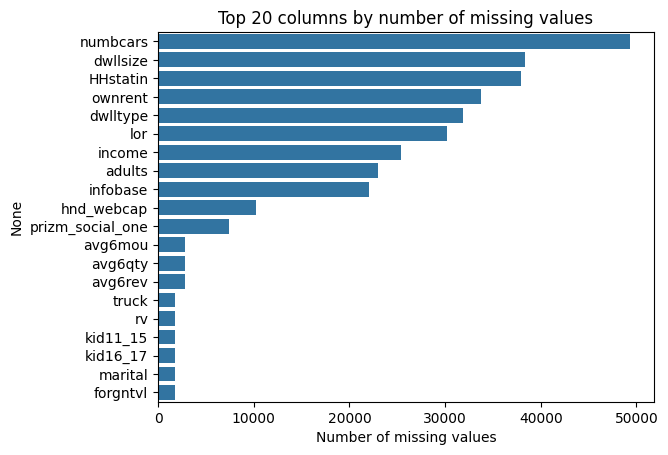

In [8]:
# Count of missing values per column
missing_counts = df.isna().sum()

# Take the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')
plt.show()

churn
0    50438
1    49562
Name: count, dtype: int64

churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64


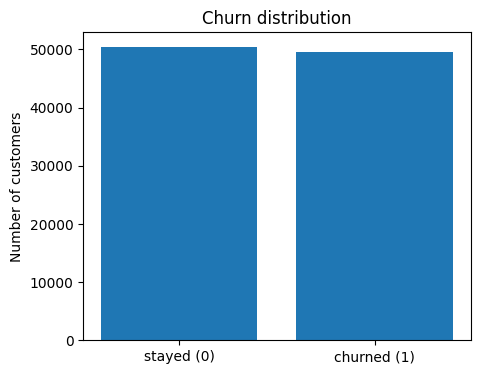

In [9]:
# Counts and proportions
print(df['churn'].value_counts())
print()
print(df['churn'].value_counts(normalize=True))

# Bar chart
counts = df['churn'].value_counts().sort_index()
labels = ['stayed (0)', 'churned (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values)
plt.title('Churn distribution')
plt.ylabel('Number of customers')
plt.show()

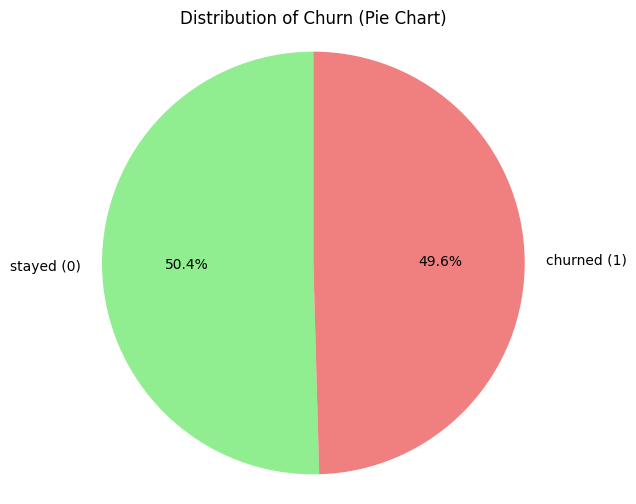

In [10]:
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'lightcoral'])
plt.title('Distribution of Churn (Pie Chart)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

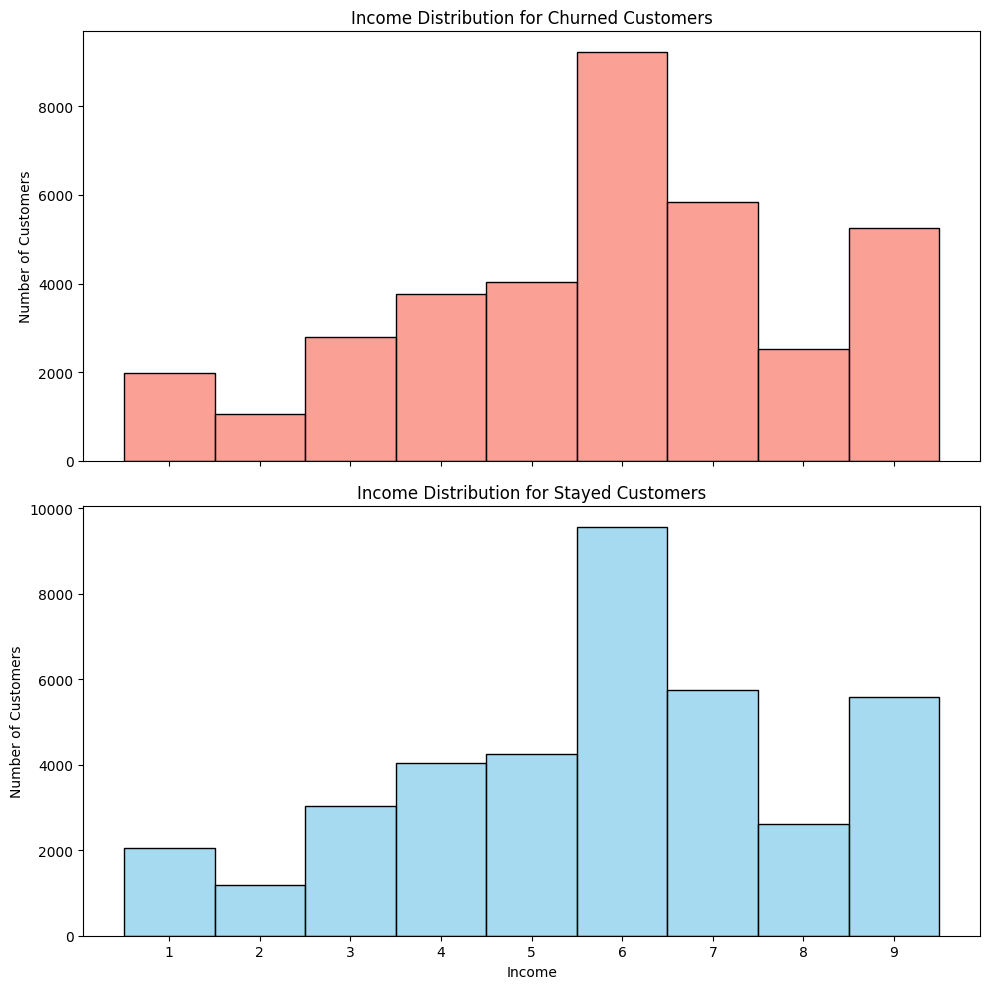

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for plotting: select 'income' and 'churn', drop NaNs for 'income'
plot_data = df[['income', 'churn']].dropna(subset=['income']).copy()

# Separate data for 'Stayed' (0) and 'Churned' (1) customers
stayed_data = plot_data[plot_data['churn'] == 0]
churned_data = plot_data[plot_data['churn'] == 1]

# Define bins to ensure each integer income value (1-9) has its own bar
bins_edges = np.arange(0.5, 10.5, 1)

# Create two subplots, one for churned and one for stayed
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Plot Churned Customers (top subplot)
sns.histplot(
    data=churned_data,
    x='income',
    bins=bins_edges,
    kde=False,
    color='salmon',
    ax=axes[0]
)
axes[0].set_title('Income Distribution for Churned Customers')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticks(np.arange(1, 10, 1))

# Plot Stayed Customers (bottom subplot)
sns.histplot(
    data=stayed_data,
    x='income',
    bins=bins_edges,
    kde=False,
    color='skyblue',
    ax=axes[1]
)
axes[1].set_title('Income Distribution for Stayed Customers')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xticks(np.arange(1, 10, 1))

plt.tight_layout()
plt.show()

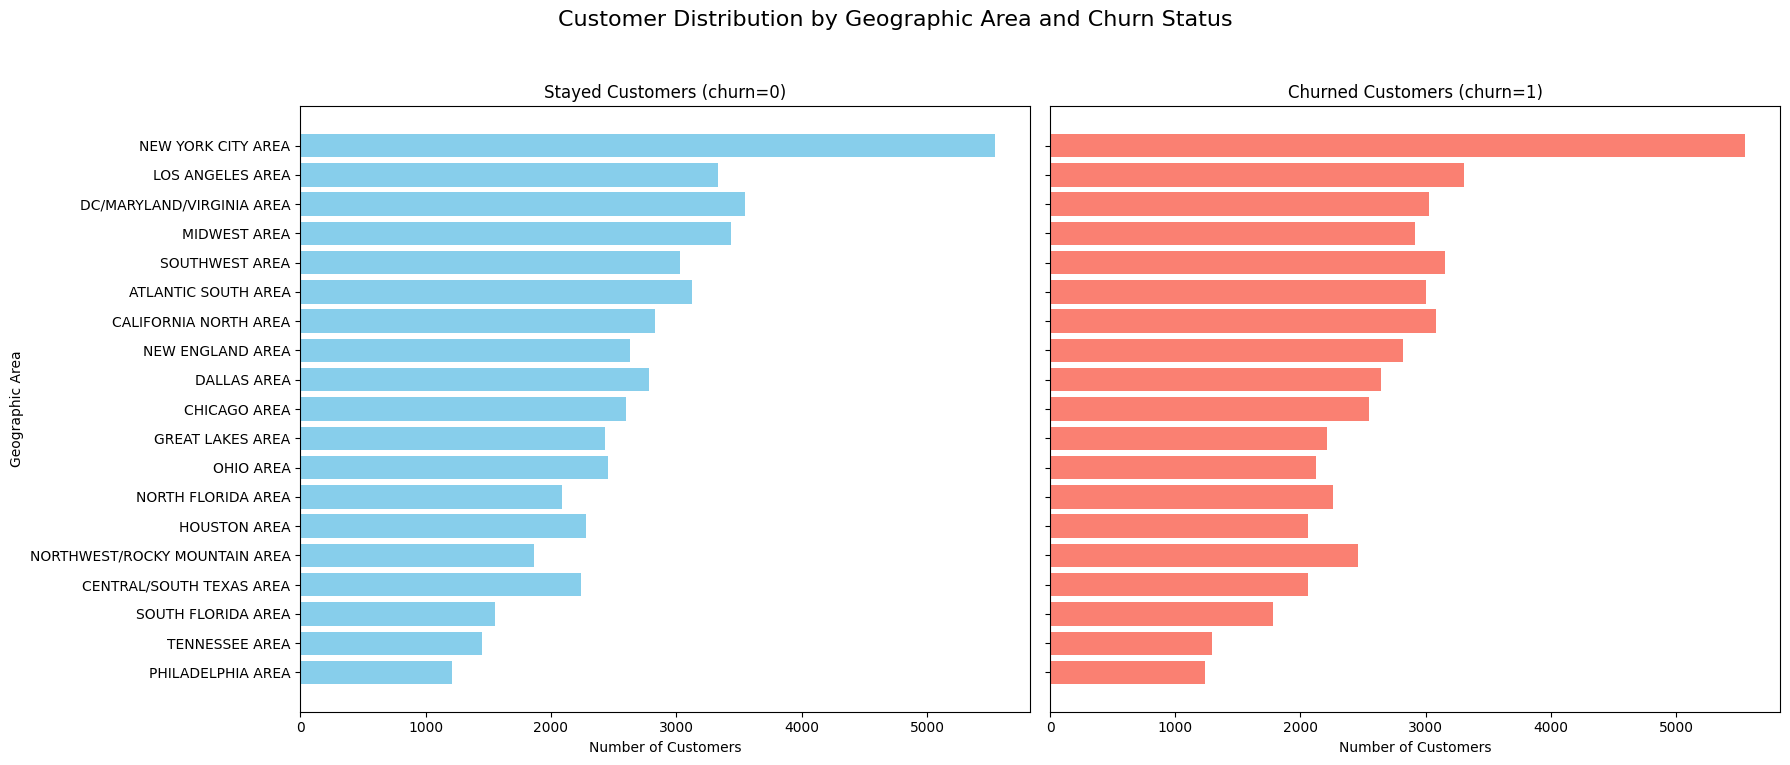

In [12]:
# Calculate the counts of customers by area and churn status
area_churn_counts = df.groupby(['area', 'churn']).size().unstack(fill_value=0)

# Calculate total customers per area to sort them
area_churn_counts['Total'] = area_churn_counts[0] + area_churn_counts[1]
area_churn_counts = area_churn_counts.sort_values(by='Total', ascending=True) # Sort ascending for better visualization in horizontal bars

# Prepare data for plotting
areas = area_churn_counts.index
stayed_counts = area_churn_counts[0]
churned_counts = area_churn_counts[1]

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True) # Create two subplots side-by-side

# Plot 'stayed' customers
axes[0].barh(areas, stayed_counts, color='skyblue')
axes[0].set_title('Stayed Customers (churn=0)')
axes[0].set_xlabel('Number of Customers')
axes[0].set_ylabel('Geographic Area')

# Plot 'churned' customers
axes[1].barh(areas, churned_counts, color='salmon')
axes[1].set_title('Churned Customers (churn=1)')
axes[1].set_xlabel('Number of Customers')

plt.suptitle('Customer Distribution by Geographic Area and Churn Status', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent labels from being cut off, and make space for suptitle
plt.show()

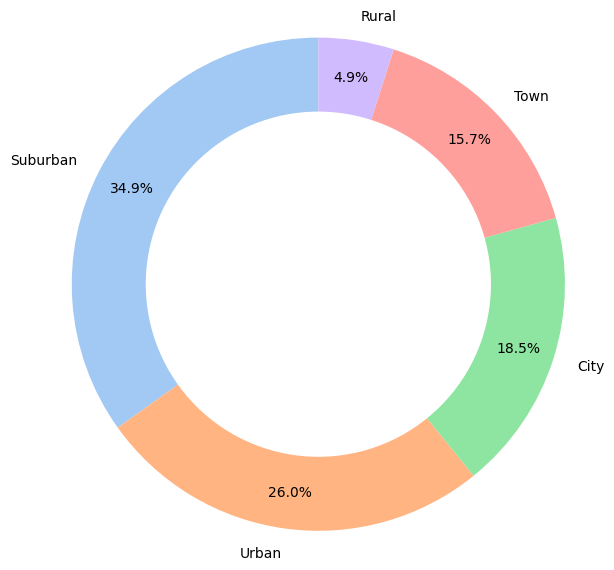

In [13]:
# Filter data for stayed customers (churn=0)
stayed_customers = df[df['churn'] == 0].dropna(subset=['prizm_social_one']).copy()
stayed_prizm_counts = stayed_customers['prizm_social_one'].value_counts()

# Map original labels to new descriptive labels
label_mapping = {
    'S': 'Suburban',
    'U': 'Urban',
    'R': 'Rural',
    'T': 'Town',
    'C': 'City'
}
labels_stayed_prizm = [label_mapping.get(x, x) for x in stayed_prizm_counts.index.tolist()]

plt.figure(figsize=(7, 7))
plt.pie(stayed_prizm_counts, labels=labels_stayed_prizm, autopct='%1.1f%%', startangle=90, pctdistance=0.85, colors=sns.color_palette('pastel'))

# Draw a white circle in the center to create a donut chart
centre_circle_stayed = plt.Circle((0,0), 0.70, fc='white')
fig_stayed = plt.gcf()
fig_stayed.gca().add_artist(centre_circle_stayed)

#plt.title('Prizm Social One Distribution for Stayed Customers', fontsize=16)
plt.axis('equal')
plt.show()

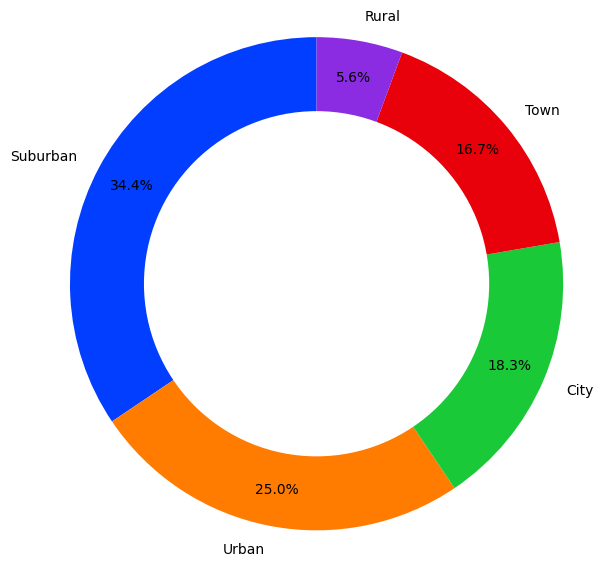

In [14]:
# Filter data for churned customers (churn=1)
churned_customers = df[df['churn'] == 1].dropna(subset=['prizm_social_one']).copy()
churned_prizm_counts = churned_customers['prizm_social_one'].value_counts()

# Map original labels to new descriptive labels
label_mapping = {
    'S': 'Suburban',
    'U': 'Urban',
    'R': 'Rural',
    'T': 'Town',
    'C': 'City'
}
labels_churned_prizm = [label_mapping.get(x, x) for x in churned_prizm_counts.index.tolist()]

plt.figure(figsize=(7, 7))
plt.pie(churned_prizm_counts, labels=labels_churned_prizm, autopct='%1.1f%%', startangle=90, pctdistance=0.85, colors=sns.color_palette('bright'))

# Draw a white circle in the center to create a donut chart
centre_circle_churned = plt.Circle((0,0), 0.70, fc='white')
fig_churned = plt.gcf()
fig_churned.gca().add_artist(centre_circle_churned)

#plt.title('Prizm Social One Distribution for Churned Customers', fontsize=16)
plt.axis('equal')
plt.show()

In [15]:
import pandas as pd

# Drop the ID column
df_clean = df.drop(columns=['Customer_ID'])

# Find all columns that are stored as text (object dtype)
object_cols = df_clean.select_dtypes(include='object').columns.tolist()
print('Columns to encode:', object_cols)

# Encode each text column as integers
for col in object_cols:
    if col == 'refurb_new':
        # Explicitly map 'N' to 0 and 'R' to 1. Any other values (e.g., NaN) will become NaN.
        df_clean[col] = df_clean[col].map({'N': 0, 'R': 1})
    else:
        encoder = LabelEncoder()
        df_clean[col] = encoder.fit_transform(df_clean[col].astype(str))

# After encoding, ensure 'refurb_new' is strictly binary and has no NaNs
df_clean.dropna(subset=['refurb_new'], inplace=True)
df_clean['refurb_new'] = df_clean['refurb_new'].astype(int) # Convert to integer type

print()
print('Shape after preprocessing:', df_clean.shape)
print(f"Unique values in df_clean['refurb_new'] after encoding: {df_clean['refurb_new'].unique()}")
df_clean.head(30)

Columns to encode: ['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']

Shape after preprocessing: (99999, 99)
Unique values in df_clean['refurb_new'] after encoding: [0 1]


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0000,0.0000,0.000,0.0000,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.000000,42.333333,0.0,45.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.000000,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.000000,132.600000,0.000000,24.000000,0.000000,55.220000,0.000000,1.333333,52.333333,45.000000,0.0,0.333333,1,61,2,1,1,0,0,1652,4228.000000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,2,13,3,0,149.98999,2.0,2.0,2,0.0,0.0,0,15.0,1,3,1.0,0,4.0,3.0,2,0,0.0,9,0,0,0,0,0,1,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1000,9.1000,0.000,0.0000,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.000000,69.000000,0.0,193.333333,0.000000,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.000000,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.000000,75.333333,0.000000,157.000000,0.000000,169.343333,0.000000,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1,1,0,21,0,14654,26400.000000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,4,3,0,0,NaN,7.0,6.0,1,1.0,1.0,2,1.0,1,3,1.0,0,5.0,1.0,2,0,0.0,16,0,0,0,0,0,1,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0000,0.0000,0.000,0.0000,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.000000,0.333333,0.0,6.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,5.193333,0.000000,1.000000,0.000000,0.233333,0.000000,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1,1,2,7,0,7903,24385.053330,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,2,6,0,0,29.98999,2.0,1.0,3,0.0,0.0,0,7.0,1,2,2.0,0,5.0,2.0,2,0,0.0,9,0,1,0,0,0,1,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0000,0.0000,0.000,0.0000,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.000000,1.333333,0.0,3.666667,0.000000,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.000000,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.000000,3.380000,0.000000,3.666667,0.000000,5.450000,0.000000,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1,1,2,4,0,1502,3065.000000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,3,3,0,0,29.98999,1.0,1.0,3,0.0,0.0,2,6.0,0,2,4.0,0,6.0,1.0,2,3,0.0,14,1,0,0,0,0,1,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0000,0.0000,0.000,0.0000,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.000000,94.666667,0.0,137.000000,0.000000,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.000000,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.000000,173.476667,0.000000,90.333333,0.000000,218.086667,0.000000,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1,1,2,0,0,4485,14028.000000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,4,10,3,0,149.98999,6.0,4.0,2,0.0,0.0,1,5.0,0,3,1.0,0,6.0,1.0,2,14,0.0,6,0,0,0,0

In [16]:
# Features (X) and target (y)
X = df_clean.drop('churn', axis=1)
y = df_clean['churn']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Define the model
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss',
    random_state=42,
)

# Train
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

Accuracy: 0.6342


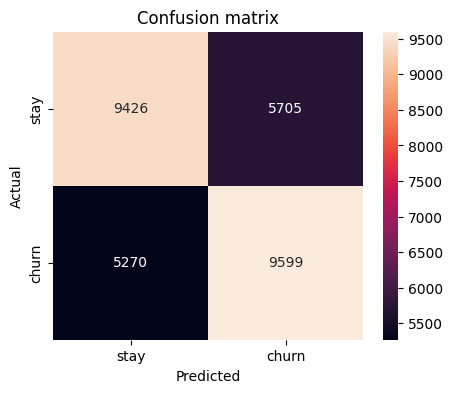

In [17]:
# Accuracy on the held-out test set
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Confusion matrix: rows = actual class, columns = predicted class
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['stay', 'churn'],
            yticklabels=['stay', 'churn'])
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

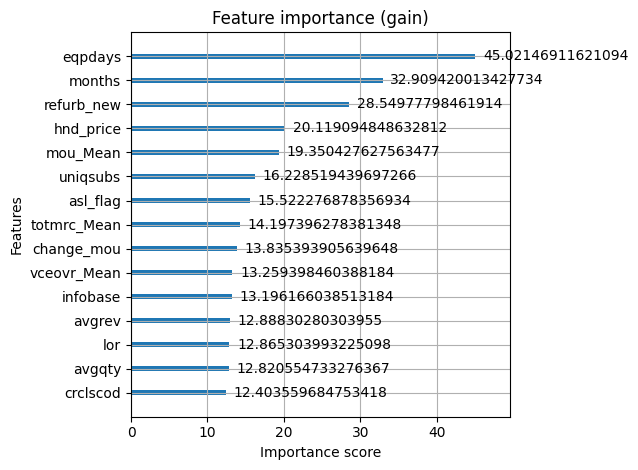

In [18]:
plot_importance(model, max_num_features=15, importance_type='gain')
plt.title('Feature importance (gain)')
plt.tight_layout()
plt.show()

refurb_new
N    85593
R    14406
Name: count, dtype: int64

refurb_new
N    0.855939
R    0.144061
Name: proportion, dtype: float64


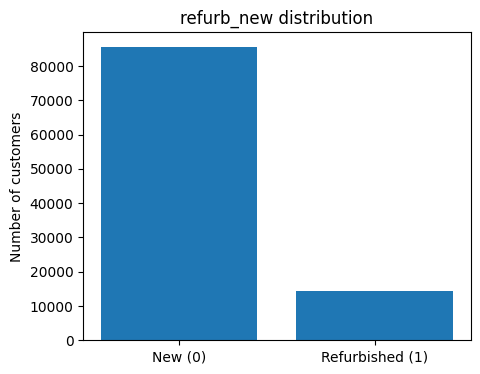

In [19]:
import matplotlib.pyplot as plt

# Counts and proportions
print(df['refurb_new'].value_counts())
print()
print(df['refurb_new'].value_counts(normalize=True))

# Bar chart
counts = df['refurb_new'].value_counts().sort_index()
labels = ['New (0)', 'Refurbished (1)'] # Updated labels for refurb_new

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values)
plt.title('refurb_new distribution') # Updated title
plt.ylabel('Number of customers')
plt.show()

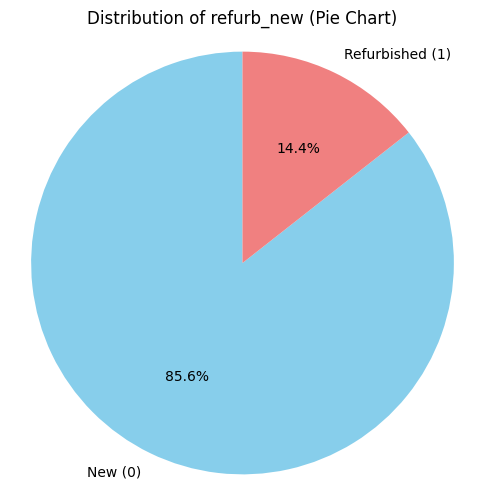

In [20]:
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of refurb_new (Pie Chart)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

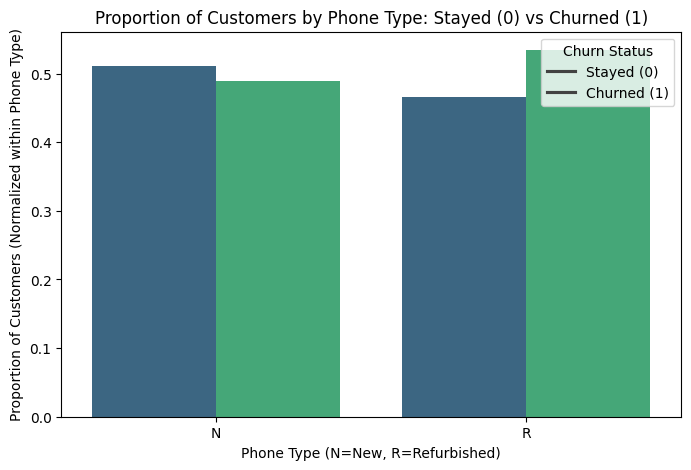


Proportional distribution of refurb_new for stayed and churned customers (within each phone type):
churn              0         1
refurb_new                    
N           0.510895  0.489105
R           0.465639  0.534361


In [21]:
# Calculate total counts for 'N' and 'R' phone types
total_n_customers = df['refurb_new'].value_counts().get('N', 0)
total_r_customers = df['refurb_new'].value_counts().get('R', 0)

# Prepare data for plotting proportions
plot_data = []

# Process 'N' (New Phones)
n_df = df[df['refurb_new'] == 'N']
n_churn_counts = n_df['churn'].value_counts()
if total_n_customers > 0:
    prop_stayed_n = n_churn_counts.get(0, 0) / total_n_customers
    prop_churned_n = n_churn_counts.get(1, 0) / total_n_customers
    plot_data.append({'refurb_new': 'N', 'churn': 0, 'proportion': prop_stayed_n})
    plot_data.append({'refurb_new': 'N', 'churn': 1, 'proportion': prop_churned_n})

# Process 'R' (Refurbished Phones)
r_df = df[df['refurb_new'] == 'R']
r_churn_counts = r_df['churn'].value_counts()
if total_r_customers > 0:
    prop_stayed_r = r_churn_counts.get(0, 0) / total_r_customers
    prop_churned_r = r_churn_counts.get(1, 0) / total_r_customers
    plot_data.append({'refurb_new': 'R', 'churn': 0, 'proportion': prop_stayed_r})
    plot_data.append({'refurb_new': 'R', 'churn': 1, 'proportion': prop_churned_r})

plot_df_proportions = pd.DataFrame(plot_data)

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df_proportions, x='refurb_new', y='proportion', hue='churn', palette='viridis')
plt.xlabel('Phone Type (N=New, R=Refurbished)')
plt.ylabel('Proportion of Customers (Normalized within Phone Type)')
plt.title('Proportion of Customers by Phone Type: Stayed (0) vs Churned (1)')
plt.legend(title='Churn Status', labels=['Stayed (0)', 'Churned (1)'])
plt.show()

print("\nProportional distribution of refurb_new for stayed and churned customers (within each phone type):")
print(plot_df_proportions.pivot(index='refurb_new', columns='churn', values='proportion').fillna(0))

In [22]:
X = df_clean.drop('refurb_new', axis=1)
y = df_clean['refurb_new']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Define the model
model1 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss',
    random_state=42,
)

# Train
model1.fit(X_train, y_train)

# Predict on the test set
y_pred = model1.predict(X_test)
y_proba = model1.predict_proba(X_test)[:, 1]

Accuracy: 0.9767 (Note: accuracy can be misleading for imbalanced datasets)
Precision: 0.9379
Recall: 0.8977
F1-score: 0.9174
AUC-ROC: 0.9953

Classification Report:
              precision    recall  f1-score   support

Refurb_new=0       0.98      0.99      0.99     25678
Refurb_new=1       0.94      0.90      0.92      4322

    accuracy                           0.98     30000
   macro avg       0.96      0.94      0.95     30000
weighted avg       0.98      0.98      0.98     30000



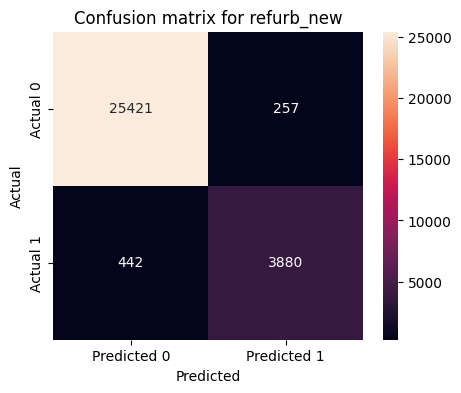

In [23]:
# Accuracy on the held-out test set
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f} (Note: accuracy can be misleading for imbalanced datasets)')

# Calculate Precision, Recall, F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

# Calculate AUC-ROC score
roc_auc = roc_auc_score(y_test, y_proba)
print(f'AUC-ROC: {roc_auc:.4f}')

# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Refurb_new=0', 'Refurb_new=1']))

# Confusion matrix: rows = actual class, columns = predicted class
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion matrix for refurb_new')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

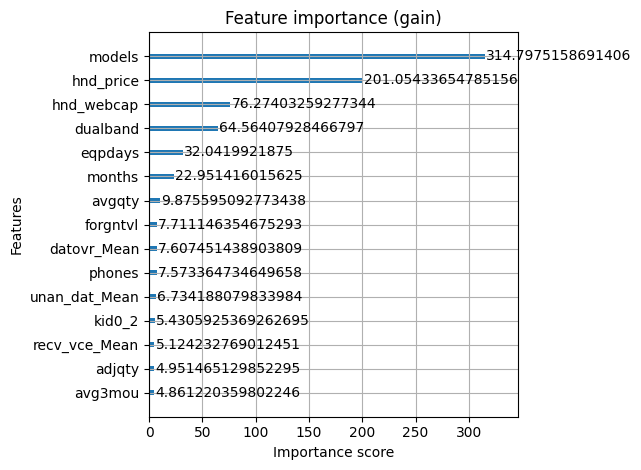

In [24]:
plot_importance(model1, max_num_features=15, importance_type='gain')
plt.title('Feature importance (gain)')
plt.tight_layout()
plt.show()

Mean number of models (new phones):        1.4
Mean number of models (refurbished phones): 2.2


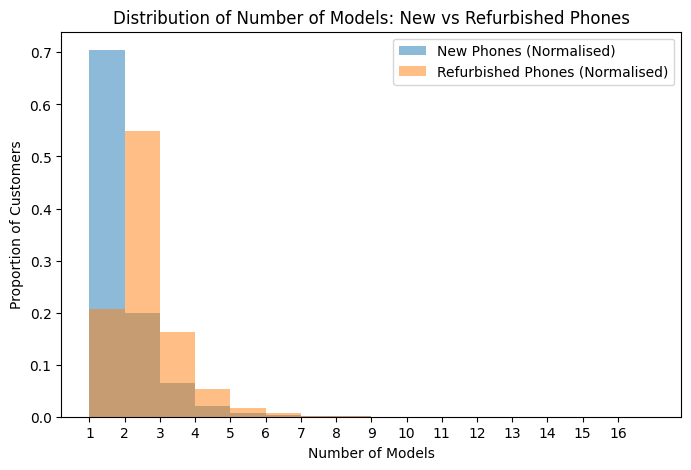

In [25]:
# Split 'models' into two groups based on 'refurb_new'
# 'N' for new, 'R' for refurbished
new_phones_models = df[df['refurb_new'] == 'N']['models'].dropna()
refurbished_phones_models = df[df['refurb_new'] == 'R']['models'].dropna()

# Compare the averages (keeping for context, though not plotted as bar chart anymore)
mean_new = new_phones_models.mean()
mean_refurbished = refurbished_phones_models.mean()

print(f'Mean number of models (new phones):        {mean_new:.1f}')
print(f'Mean number of models (refurbished phones): {mean_refurbished:.1f}')

# Overlay the two distributions as histograms
plt.figure(figsize=(8, 5))
# Plot new phones with weights to divide customer count by 4
plt.hist(new_phones_models, bins=range(int(new_phones_models.min()), int(new_phones_models.max()) + 2), alpha=0.5, label='New Phones (Normalised)', weights=np.full_like(new_phones_models, 1/85593))
plt.hist(refurbished_phones_models, bins=range(int(refurbished_phones_models.min()), int(refurbished_phones_models.max()) + 2), alpha=0.5, label='Refurbished Phones (Normalised)', weights=np.full_like(refurbished_phones_models, 1/14406))
plt.xlabel('Number of Models')
plt.ylabel('Proportion of Customers')
plt.title('Distribution of Number of Models: New vs Refurbished Phones')
plt.legend()
plt.xticks(range(int(new_phones_models.min()), int(max(new_phones_models.max(), refurbished_phones_models.max())) + 1))
plt.show()

Mean handset price (new phones):         109.1
Mean handset price (refurbished phones): 59.4


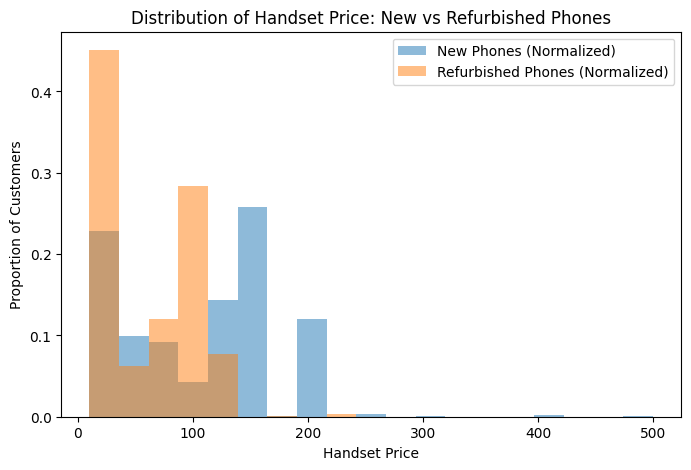

In [26]:
# Split 'hnd_price' into two groups based on 'refurb_new'
# 'N' for new, 'R' for refurbished
new_phones_hnd_price = df[df['refurb_new'] == 'N']['hnd_price'].dropna()
refurbished_phones_hnd_price = df[df['refurb_new'] == 'R']['hnd_price'].dropna()

# Compare the averages (keeping for context)
mean_new_price = new_phones_hnd_price.mean()
mean_refurbished_price = refurbished_phones_hnd_price.mean()

print(f'Mean handset price (new phones):         {mean_new_price:.1f}')
print(f'Mean handset price (refurbished phones): {mean_refurbished_price:.1f}')

# Overlay the two distributions as histograms
plt.figure(figsize=(8, 5))

# Determine common bins for both distributions
min_price = min(new_phones_hnd_price.min(), refurbished_phones_hnd_price.min())
max_price = max(new_phones_hnd_price.max(), refurbished_phones_hnd_price.max())
bins = np.linspace(min_price, max_price, 20) # Use 50 bins for better resolution

# Plot new phones with weights (normalized by total N customers)
plt.hist(new_phones_hnd_price, bins=bins, alpha=0.5, label='New Phones (Normalized)', weights=np.full_like(new_phones_hnd_price, 1/85593))
# Plot refurbished phones with weights (normalized by total R customers)
plt.hist(refurbished_phones_hnd_price, bins=bins, alpha=0.5, label='Refurbished Phones (Normalized)', weights=np.full_like(refurbished_phones_hnd_price, 1/14406))

plt.xlabel('Handset Price')
plt.ylabel('Proportion of Customers')
plt.title('Distribution of Handset Price: New vs Refurbished Phones')
plt.legend()
plt.show()